# NiVScan — Model C:

---

| | |
|---|---|
| **Mata Kuliah** | COMP6885001 — Natural Language Processing |
| **Model** |  (BioBERT, domain biomedis) |
| **Task** | Named Entity Recognition — DISEASE, SYMPTOM, LOCATION |
| **Runtime** | GPU (T4 Colab) |
| **Input** | , ,  |
| **Output** |  (checkpoint terbaik) |

---

## ⚠️ Baca Dulu!
- Pastikan **Runtime → Change runtime type → T4 GPU** sebelum jalankan
- Step 0 dan Step 1 harus sudah selesai (file IOB sudah ada di Drive)
- Setiap epoch otomatis disimpan ke Drive — aman kalau Colab disconnect
- Early stopping aktif — training otomatis berhenti kalau val F1 tidak improve

## 📌 Catatan Model C
Model  adalah BioBERT yang sudah di-pre-train di literatur biomedis.
Diharapkan lebih baik dari Model B khususnya untuk entitas **DISEASE** dan **SYMPTOM**,
karena memiliki pengetahuan domain medis yang lebih dalam.

---
## 1. Cek GPU & Install Library

In [1]:
# Cek GPU tersedia
import torch
print(f'CUDA available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU            : {torch.cuda.get_device_name(0)}')
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'VRAM           : {total_mem:.1f} GB')
else:
    print('GPU tidak terdeteksi!')
    print('   → Ganti runtime: Runtime → Change runtime type → T4 GPU')

CUDA available : True
GPU            : Tesla T4
VRAM           : 14.6 GB


In [2]:
!pip install -q transformers datasets seqeval accelerate
print('Library berhasil diinstall!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Library berhasil diinstall!


In [3]:
import os
import json
import numpy as np
import pandas as pd
from collections import Counter

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorForTokenClassification
)
from datasets import Dataset
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score

print('Semua library berhasil diimport!')
print(f'   transformers : {__import__("transformers").__version__}')
print(f'   torch        : {torch.__version__}')

Semua library berhasil diimport!
   transformers : 5.0.0
   torch        : 2.10.0+cu128


---
## 2. Mount Google Drive & Set Path

In [4]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive berhasil terhubung!')

Mounted at /content/drive
Google Drive berhasil terhubung!


In [5]:
BASE_PATH = '/content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Dataset'
MODEL_PATH = '/content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Models/model_C'

PATH_TRAIN_IOB = f'{BASE_PATH}/dataset_train_iob.json'
PATH_VAL_IOB   = f'{BASE_PATH}/dataset_val_iob.json'
PATH_TEST_IOB  = f'{BASE_PATH}/dataset_test_iob.json'

# Buat folder model kalau belum ada
os.makedirs(MODEL_PATH, exist_ok=True)

print('Path dataset:')
print(f'   Train : {PATH_TRAIN_IOB}')
print(f'   Val   : {PATH_VAL_IOB}')
print(f'   Test  : {PATH_TEST_IOB}')
print(f'   Model : {MODEL_PATH}')

Path dataset:
   Train : /content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Dataset/dataset_train_iob.json
   Val   : /content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Dataset/dataset_val_iob.json
   Test  : /content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Dataset/dataset_test_iob.json
   Model : /content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Models/model_C


---
## 3. Load Dataset IOB

In [6]:
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

for p in [PATH_TRAIN_IOB, PATH_VAL_IOB, PATH_TEST_IOB]:
    assert os.path.exists(p), f' File tidak ditemukan: {p}\n   → Jalankan Step 1 terlebih dahulu!'

train_data = load_json(PATH_TRAIN_IOB)
val_data   = load_json(PATH_VAL_IOB)
test_data  = load_json(PATH_TEST_IOB)

print('Dataset IOB berhasil diload!')
print(f'   Train : {len(train_data)} kalimat')
print(f'   Val   : {len(val_data)} kalimat')
print(f'   Test  : {len(test_data)} kalimat')
print()
print('Contoh 1 item train:')
sample = train_data[0]
for tok, tag in zip(sample['tokens'], sample['ner_tags']):
    print(f'   {tok:25s} → {tag}')

Dataset IOB berhasil diload!
   Train : 574 kalimat
   Val   : 144 kalimat
   Test  : 179 kalimat

Contoh 1 item train:
   No                        → O
   infection                 → O
   of                        → O
   humans                    → O
   or                        → O
   other                     → O
   species                   → O
   has                       → O
   been                      → O
   observed                  → O
   in                        → O
   Cambodia                  → B-LOCATION
   ,                         → O
   Thailand                  → B-LOCATION
   ,                         → O
   or                        → O
   Africa                    → B-LOCATION
   as                        → O
   of                        → O
   May                       → O
   2018                      → O
   .                         → O


---
## 4. Label Mapping

In [7]:
# Kumpulkan semua label unik dari train + val + test
all_tags = set()
for split in [train_data, val_data, test_data]:
    for item in split:
        all_tags.update(item['ner_tags'])

# Urutkan: O dulu, lalu B- dan I- secara alfabetis
label_list = sorted(all_tags, key=lambda x: (x != 'O', x))

label2id = {label: idx for idx, label in enumerate(label_list)}
id2label = {idx: label for label, idx in label2id.items()}

print(f'Label mapping berhasil dibuat!')
print(f'   Total label : {len(label_list)}')
print()
for label, idx in label2id.items():
    print(f'   {idx} → {label}')

Label mapping berhasil dibuat!
   Total label : 7

   0 → O
   1 → B-DISEASE
   2 → B-LOCATION
   3 → B-SYMPTOM
   4 → I-DISEASE
   5 → I-LOCATION
   6 → I-SYMPTOM


---
## 5. Tokenisasi & Alignment Label

BERT menggunakan WordPiece tokenizer — satu kata bisa dipecah jadi beberapa subword token.
Contoh: `"Malaysia"` → `["Mal", "##aysia"]`

Label hanya diberikan ke token pertama dari setiap kata (`-100` untuk subword berikutnya
supaya tidak ikut dihitung saat evaluasi).

In [8]:
MODEL_NAME = 'd4data/biomedical-ner-all'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f'Tokenizer berhasil diload: {MODEL_NAME}')
print(f'   Vocab size     : {tokenizer.vocab_size}')
print(f'   Max length     : {tokenizer.model_max_length}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Tokenizer berhasil diload: d4data/biomedical-ner-all
   Vocab size     : 30522
   Max length     : 512


In [9]:
def tokenize_and_align_labels(examples):
    """
    Tokenisasi dengan WordPiece dan align label ke subword tokens.
    Subword token ke-2 dst dari 1 kata diberi label -100 (diabaikan saat loss/eval).
    """
    tokenized = tokenizer(
        examples['tokens'],
        truncation=True,
        max_length=128,          # cukup untuk kalimat Nipah
        is_split_into_words=True # input sudah berupa list token
    )

    all_labels = []
    for i, label_seq in enumerate(examples['ner_tags']):
        word_ids     = tokenized.word_ids(batch_index=i)
        prev_word_id = None
        aligned      = []

        for word_id in word_ids:
            if word_id is None:
                # Token spesial [CLS] dan [SEP]
                aligned.append(-100)
            elif word_id != prev_word_id:
                # Token pertama dari sebuah kata → pakai label asli
                aligned.append(label2id[label_seq[word_id]])
            else:
                # Subword berikutnya → -100 (diabaikan)
                aligned.append(-100)
            prev_word_id = word_id

        all_labels.append(aligned)

    tokenized['labels'] = all_labels
    return tokenized


print('Fungsi tokenisasi berhasil didefinisikan!')
print()

# Test dengan 1 contoh
sample = train_data[0]
test_enc = tokenizer(
    sample['tokens'],
    is_split_into_words=True,
    max_length=128,
    truncation=True
)
print('🧪 Test tokenisasi (5 token pertama):')
for token_id, word_id in zip(test_enc['input_ids'][:7], test_enc.word_ids()[:7]):
    decoded = tokenizer.decode([token_id])
    print(f'   token_id={token_id:6d}  word_id={str(word_id):4s}  decoded={decoded}')

Fungsi tokenisasi berhasil didefinisikan!

🧪 Test tokenisasi (5 token pertama):
   token_id=   101  word_id=None  decoded=[CLS]
   token_id=  2053  word_id=0     decoded=no
   token_id=  8985  word_id=1     decoded=infection
   token_id=  1997  word_id=2     decoded=of
   token_id=  4286  word_id=3     decoded=humans
   token_id=  2030  word_id=4     decoded=or
   token_id=  2060  word_id=5     decoded=other


In [10]:
# Konversi ke HuggingFace Dataset
def to_hf_dataset(data):
    return Dataset.from_dict({
        'tokens'  : [d['tokens']   for d in data],
        'ner_tags': [d['ner_tags'] for d in data],
        'id'      : [d['id']       for d in data],
    })

train_hf = to_hf_dataset(train_data)
val_hf   = to_hf_dataset(val_data)
test_hf  = to_hf_dataset(test_data)

# Tokenisasi semua split
print('Tokenisasi dataset...')
train_enc = train_hf.map(tokenize_and_align_labels, batched=True, remove_columns=['tokens','ner_tags','id'])
val_enc   = val_hf.map(tokenize_and_align_labels,   batched=True, remove_columns=['tokens','ner_tags','id'])
test_enc  = test_hf.map(tokenize_and_align_labels,  batched=True, remove_columns=['tokens','ner_tags','id'])

print('Tokenisasi selesai!')
print(f'   Train : {len(train_enc)} samples')
print(f'   Val   : {len(val_enc)} samples')
print(f'   Test  : {len(test_enc)} samples')

Tokenisasi dataset...


Map:   0%|          | 0/574 [00:00<?, ? examples/s]

Map:   0%|          | 0/144 [00:00<?, ? examples/s]

Map:   0%|          | 0/179 [00:00<?, ? examples/s]

Tokenisasi selesai!
   Train : 574 samples
   Val   : 144 samples
   Test  : 179 samples


---
## 6. Load Model

In [11]:
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True  # head classifier diganti sesuai label kita
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Model berhasil diload: {MODEL_NAME}')
print(f'   Device           : {device}')
print(f'   Total params     : {total_params:,}')
print(f'   Trainable params : {trainable_params:,}')
print(f'   Num labels       : {len(label_list)}')

model.safetensors:   0%|          | 0.00/266M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: d4data/biomedical-ner-all
Key               | Status   |                                                                                      
------------------+----------+--------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([84]) vs model:torch.Size([7])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([84, 768]) vs model:torch.Size([7, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Model berhasil diload: d4data/biomedical-ner-all
   Device           : cuda
   Total params     : 66,368,263
   Trainable params : 66,368,263
   Num labels       : 7


---
## 7. Training Configuration

Konfigurasi dioptimalkan untuk GPU T4 (16GB VRAM):
- **Batch size 32** — maksimal untuk T4 dengan BERT-base dan max_length=128
- **Gradient accumulation 2** — efektif batch size = 64
- **Checkpoint tiap epoch** — langsung disimpan ke Drive
- **Early stopping patience=3** — stop kalau val F1 tidak naik 3 epoch berturut-turut
- **load_best_model_at_end=True** — otomatis load checkpoint terbaik di akhir

In [12]:
def compute_metrics(eval_pred):
    """Hitung Precision, Recall, F1 menggunakan seqeval (entity-level)."""
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=-1)

    true_labels = []
    true_preds  = []

    for pred_seq, label_seq in zip(predictions, labels):
        true_label_row = []
        true_pred_row  = []
        for pred, label in zip(pred_seq, label_seq):
            if label == -100:
                continue  # skip subword tokens dan special tokens
            true_label_row.append(id2label[label])
            true_pred_row.append(id2label[pred])
        true_labels.append(true_label_row)
        true_preds.append(true_pred_row)

    return {
        'precision': precision_score(true_labels, true_preds),
        'recall'   : recall_score(true_labels, true_preds),
        'f1'       : f1_score(true_labels, true_preds),
    }

print('Fungsi compute_metrics berhasil didefinisikan!')

Fungsi compute_metrics berhasil didefinisikan!


In [14]:
CHECKPOINT_DIR = f'{MODEL_PATH}/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

training_args = TrainingArguments(
    output_dir                  = CHECKPOINT_DIR,

    # ── Batch & Epoch ──────────────────────────────────────
    num_train_epochs            = 50,          # max epoch, early stopping yang atur
    per_device_train_batch_size = 32,          # optimal untuk T4 + BERT-base
    per_device_eval_batch_size  = 64,          # eval bisa lebih besar (no gradient)
    gradient_accumulation_steps = 2,           # effective batch = 64

    # ── Checkpoint — simpan tiap epoch ke Drive ────────────
    save_strategy               = 'epoch',
    save_total_limit            = 3,           # simpan 3 checkpoint terbaik saja

    # ── Evaluasi ──────────────────────────────────────────
    eval_strategy               = 'epoch',
    metric_for_best_model       = 'f1',
    greater_is_better           = True,
    load_best_model_at_end      = True,        # otomatis load checkpoint terbaik

    # ── Learning Rate ─────────────────────────────────────
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,

    # ── Optimasi GPU ──────────────────────────────────────
    fp16                        = True,        # mixed precision — hemat VRAM ~30%
    gradient_checkpointing      = True,        # hemat VRAM saat backprop
    dataloader_num_workers      = 2,

    # ── Logging ───────────────────────────────────────────
    logging_dir                 = f'{MODEL_PATH}/logs',
    logging_steps               = 10,
    report_to                   = 'none',      # matikan wandb
)

print('Training arguments berhasil dikonfigurasi!')
print(f'   Batch size per device   : {training_args.per_device_train_batch_size}')
print(f'   Gradient accumulation   : {training_args.gradient_accumulation_steps}')
print(f'   Effective batch size    : {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}')
print(f'   Max epochs              : {training_args.num_train_epochs}')
print(f'   FP16 mixed precision    : {training_args.fp16}')
print(f'   Gradient checkpointing  : {training_args.gradient_checkpointing}')
print(f'   Early stopping patience : 3 epoch')
print(f'   Checkpoint dir          : {CHECKPOINT_DIR}')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training arguments berhasil dikonfigurasi!
   Batch size per device   : 32
   Gradient accumulation   : 2
   Effective batch size    : 64
   Max epochs              : 50
   FP16 mixed precision    : True
   Gradient checkpointing  : True
   Early stopping patience : 3 epoch
   Checkpoint dir          : /content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Models/model_C/checkpoints


In [15]:
data_collator = DataCollatorForTokenClassification(tokenizer)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_enc,
    eval_dataset    = val_enc,
    data_collator   = data_collator,
    compute_metrics = compute_metrics,
    callbacks       = [
        EarlyStoppingCallback(
            early_stopping_patience  = 3,    # stop kalau 3 epoch tidak improve
            early_stopping_threshold = 0.001 # minimal improvement 0.1%
        )
    ]
)

print('Trainer berhasil dikonfigurasi!')

Trainer berhasil dikonfigurasi!


---
## 8. Training

In [16]:
print('Memulai training...')
print('   Checkpoint disimpan ke Drive tiap epoch.')
print('   Training akan otomatis berhenti kalau val F1 tidak naik 3 epoch berturut-turut.')
print()

train_result = trainer.train()

print()
print('Training selesai!')
print(f'   Total steps  : {train_result.global_step}')
print(f'   Training loss: {train_result.training_loss:.4f}')

Memulai training...
   Checkpoint disimpan ke Drive tiap epoch.
   Training akan otomatis berhenti kalau val F1 tidak naik 3 epoch berturut-turut.



Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,No log,1.626580,0.018245,0.264286,0.034133
2,3.584824,0.984715,0.000000,0.000000,0.000000
3,2.523815,0.391671,0.000000,0.000000,0.000000
4,1.097994,0.265275,0.166667,0.021429,0.037975
5,0.647868,0.165983,0.953846,0.442857,0.604878
6,0.407336,0.100108,0.894231,0.664286,0.762295
7,0.210824,0.079601,0.843284,0.807143,0.824818
8,0.157350,0.058435,0.906977,0.835714,0.869888
9,0.106514,0.055315,0.867647,0.842857,0.855072
10,0.077295,0.054453,0.877698,0.871429,0.874552


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Training selesai!
   Total steps  : 153
   Training loss: 0.5896


---
## 9. Simpan Model Final ke Drive

In [17]:
FINAL_MODEL_PATH = f'{MODEL_PATH}/model_C_final'
os.makedirs(FINAL_MODEL_PATH, exist_ok=True)

# Simpan model terbaik (sudah di-load otomatis karena load_best_model_at_end=True)
trainer.save_model(FINAL_MODEL_PATH)
tokenizer.save_pretrained(FINAL_MODEL_PATH)

print(f'✅ Model final berhasil disimpan!')
print(f'   Path: {FINAL_MODEL_PATH}')
print()

# Cek ukuran file
total_size = 0
for f in os.listdir(FINAL_MODEL_PATH):
    fpath = os.path.join(FINAL_MODEL_PATH, f)
    size  = os.path.getsize(fpath)
    total_size += size
    print(f'   {f:40s} {size/1024**2:.1f} MB')
print(f'   {"TOTAL":40s} {total_size/1024**2:.1f} MB')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model final berhasil disimpan!
   Path: /content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Models/model_C/model_C_final

   config.json                              0.0 MB
   model.safetensors                        253.2 MB
   tokenizer_config.json                    0.0 MB
   tokenizer.json                           0.7 MB
   training_args.bin                        0.0 MB
   TOTAL                                    253.9 MB


---
## 10. Evaluasi Final di `dataset_test_iob.json`

In [20]:
print('Evaluasi di test set (179 kalimat ANNOTATED_DATA)...')

predictions, labels, _ = trainer.predict(test_enc)
preds = np.argmax(predictions, axis=-1)

true_labels = []
true_preds  = []

for pred_seq, label_seq in zip(preds, labels):
    true_label_row = []
    true_pred_row  = []
    for pred, label in zip(pred_seq, label_seq):
        if label == -100:
            continue
        true_label_row.append(id2label[label])
        true_pred_row.append(id2label[pred])
    true_labels.append(true_label_row)
    true_preds.append(true_pred_row)

print()
print('=' * 62)
print('  EVALUASI MODEL C — d4data/biomedical-ner-all')
print('  Test set: dataset_test_iob.json (179 kalimat manual)')
print('=' * 62)
print()
print(classification_report(true_labels, true_preds))

Evaluasi di test set (179 kalimat ANNOTATED_DATA)...



  EVALUASI MODEL C — d4data/biomedical-ner-all
  Test set: dataset_test_iob.json (179 kalimat manual)

              precision    recall  f1-score   support

     DISEASE       0.96      0.96      0.96        94
    LOCATION       0.67      0.61      0.64        69
     SYMPTOM       0.29      0.25      0.27         8

   micro avg       0.82      0.78      0.80       171
   macro avg       0.64      0.61      0.62       171
weighted avg       0.81      0.78      0.80       171



In [21]:
from seqeval.metrics import classification_report as seq_report
import numpy as np

def convert_numpy_to_python(obj):
    if isinstance(obj, np.integer): return int(obj)
    elif isinstance(obj, np.floating): return float(obj)
    elif isinstance(obj, np.ndarray): return obj.tolist()
    raise TypeError(f"Object of type {obj.__class__.__name__} is not JSON serializable")

macro_p  = precision_score(true_labels, true_preds)
macro_r  = recall_score(true_labels, true_preds)
macro_f1 = f1_score(true_labels, true_preds)

# Simpan hasil evaluasi ke JSON
eval_results = {
    'model'     : 'Model C — d4data/biomedical-ner-all',
    'test_set'  : 'dataset_test_iob.json (100 kalimat manual)',
    'macro': {
        'precision': round(float(macro_p), 4),
        'recall'   : round(float(macro_r), 4),
        'f1'       : round(float(macro_f1), 4)
    },
    'per_entity': seq_report(true_labels, true_preds, output_dict=True)
}

RESULT_PATH = f'{MODEL_PATH}/eval_results_model_C.json'
with open(RESULT_PATH, 'w', encoding='utf-8') as f:
    json.dump(eval_results, f, ensure_ascii=False, indent=2, default=convert_numpy_to_python)

print('Hasil evaluasi disimpan!')
print(f'   Path: {RESULT_PATH}')
print()
print('Ringkasan Macro Average:')
print(f'   Precision : {macro_p:.4f}')
print(f'   Recall    : {macro_r:.4f}')
print(f'   F1 Score  : {macro_f1:.4f}')

Hasil evaluasi disimpan!
   Path: /content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Models/model_C/eval_results_model_C.json

Ringkasan Macro Average:
   Precision : 0.8171
   Recall    : 0.7836
   F1 Score  : 0.8000


In [22]:
print('=' * 62)
print('  MODEL B SELESAI!')
print('=' * 62)
print()
print('File yang tersimpan di Drive:')
print(f'   {FINAL_MODEL_PATH}/')
print(f'   {RESULT_PATH}')
print()
print('Hasil untuk tabel komparasi laporan:')
print(f'   Model C (d4data/biomedical-ner-all)')
print(f'   Precision : {macro_p:.4f}')
print(f'   Recall    : {macro_r:.4f}')
print(f'   F1 Score  : {macro_f1:.4f}')
print()

  MODEL B SELESAI!

File yang tersimpan di Drive:
   /content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Models/model_C/model_C_final/
   /content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Models/model_C/eval_results_model_C.json

Hasil untuk tabel komparasi laporan:
   Model C (d4data/biomedical-ner-all)
   Precision : 0.8171
   Recall    : 0.7836
   F1 Score  : 0.8000



---
## 11. Visualisasi Perbandingan Model

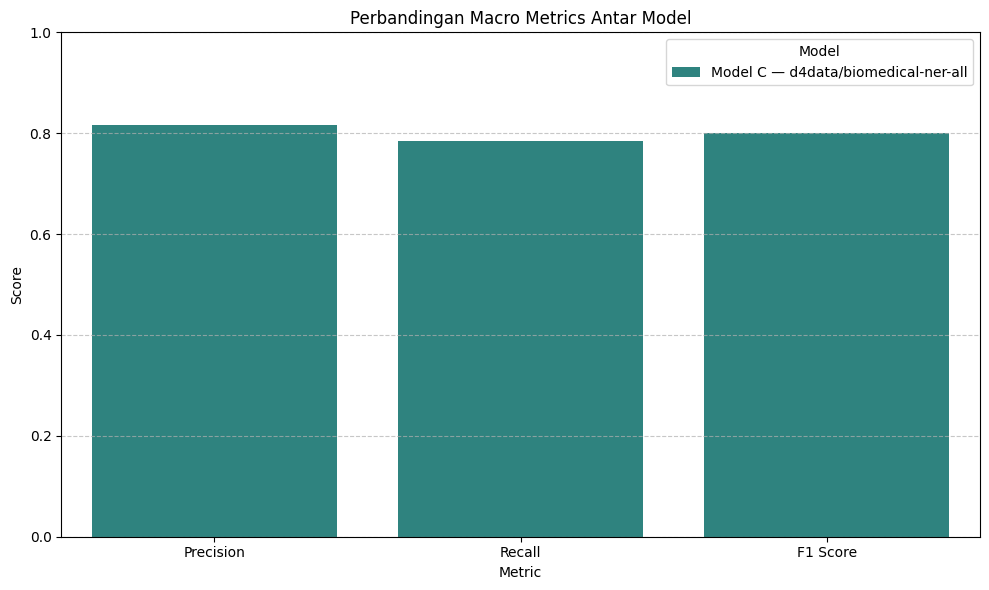

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pandas as pd
import os

def load_eval_results(model_path, result_filename='eval_results.json'):
    """Loads evaluation results from a JSON file."""
    path = os.path.join(model_path, result_filename)
    if os.path.exists(path):
        with open(path, 'r', encoding='utf-8') as f:
            return json.load(f)
    else:
        print(f"Warning: Evaluation result file not found at {path}")
        return None

# Initialize a list to store metrics for all models
all_model_metrics = []

# Load results for Model C (assuming RESULT_PATH from previous cells)
model_c_results = load_eval_results(MODEL_PATH, result_filename='eval_results_model_C.json')

if model_c_results:
    all_model_metrics.append({
        'Model': model_c_results['model'],
        'Precision': model_c_results['macro']['precision'],
        'Recall': model_c_results['macro']['recall'],
        'F1 Score': model_c_results['macro']['f1']
    })

# Example for adding another model (if available)
# model_b_path = '/content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Models/model_B'
# model_b_results = load_eval_results(model_b_path, result_filename='eval_results_model_B.json')
# if model_b_results:
#     all_model_metrics.append({
#         'Model': model_b_results['model'],
#         'Precision': model_b_results['macro']['precision'],
#         'Recall': model_b_results['macro']['recall'],
#         'F1 Score': model_b_results['macro']['f1']
#     })


if all_model_metrics:
    metrics_df = pd.DataFrame(all_model_metrics)

    # Melt the DataFrame for easier plotting with seaborn
    melted_df = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

    plt.figure(figsize=(10, 6))
    # Modified: Changed hue to 'Metric' to differentiate colors for Precision, Recall, and F1
    sns.barplot(data=melted_df, x='Metric', y='Score', hue='Metric', palette='viridis', legend=False)
    plt.title('Perbandingan Macro Metrics Antar Model')
    plt.ylabel('Score')
    plt.ylim(0, 1) # Metrics are between 0 and 1
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No model evaluation results found to plot.")

---
## 12. Confusion Matrix (Token-level)

<Figure size 1000x800 with 0 Axes>

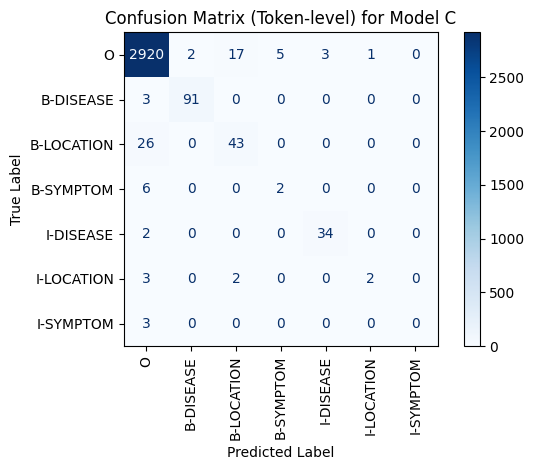

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Flatten the list of lists for true labels and predicted labels
flat_true_labels = [item for sublist in true_labels for item in sublist]
flat_true_preds = [item for sublist in true_preds for item in sublist]

# Convert string labels to numerical IDs using the label2id mapping
# Ensure all unique labels in true_labels and true_preds are covered by label2id
# and handle potential unseen labels if any (though unlikely here if `label_list` was comprehensive)

# Filter labels to only include those present in true_labels and true_preds
# and maintain order from label_list
labels_to_show = [label for label in label_list if label in set(flat_true_labels + flat_true_preds)]

# Convert actual and predicted labels to their numerical IDs
y_true = [label2id[label] for label in flat_true_labels]
y_pred = [label2id[label] for label in flat_true_preds]

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[label2id[label] for label in labels_to_show])

plt.figure(figsize=(10, 8))
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_to_show)
cmd.plot(cmap='Blues', xticks_rotation='vertical', values_format='d')
plt.title('Confusion Matrix (Token-level) for Model C')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()